In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import math 

### model prediction using vectorisation 

In [2]:
def predict(inputs,weights,bias):
    y = np.dot(inputs,weights) +bias
    return y 

### computing cost of parameters

In [3]:
def compute_cost(inputs,output,weights,bias):
    cost =0 
    m = inputs.shape[0]
    for i in range(m):
        cost += (predict(inputs[i],weights,bias)-output[i])**2
    cost /= 2 * m
    return cost 

In [4]:
def compute_gradients(inputs,outputs,weights,bias):
    m,n = inputs.shape
    dj_dw = np.zeros((n,))
    dj_db = 0 
    for i in range(m):
        err = (predict(inputs[i],weights,bias) - outputs[i])
        for j in range(n):
            dj_dw[j] += err * inputs[i,j]
        dj_db += err
    dj_dw /= m
    dj_db /= m
    return dj_dw,dj_db

In [5]:
def gradient_descent(inputs,outputs,weights_in,bias_in,alpha,iterations,tolerance=1e-4):
    j_hist = []
    weights = weights_in
    bias = bias_in
    for i in range(iterations):
        dj_dw,dj_db = compute_gradients(inputs, outputs, weights, bias)
        weights = weights - alpha* dj_dw
        bias = bias - alpha* dj_db
        current_cost =compute_cost(inputs, outputs, weights, bias)
        
        if i<100000:
            j_hist.append(current_cost)

        if i > 0:
            cost_decrease = j_hist[-2] - current_cost
            if cost_decrease < tolerance:
                print(f"Converged early at iteration {i}! Cost decrease ({cost_decrease:.6f}) is below tolerance.")
                break
        if i% math.ceil(iterations / 10) == 0:
            print(f"Iteration {i:4d}: Cost {j_hist[-1]:8.2f}   ")
        
    return weights, bias, j_hist

In [6]:
def linear_regression(inputs,outputs,iterations=10000,alpha=0.1):
    m,n = inputs.shape
    intial_weights = np.zeros(n)
    intial_bias = 0.
    w_final, b_final, J_hist = gradient_descent(inputs, outputs, intial_weights, intial_bias, alpha, iterations)
    print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
    return w_final,b_final,J_hist
    

In [7]:
def train_test_split(x, y, test_size=0.25):
    
    # Shuffle indices
    shuffled_indices = x.sample(frac=1, random_state=42).index

    x = x.loc[shuffled_indices].reset_index(drop=True)
    y = y.loc[shuffled_indices].reset_index(drop=True)

    train_size = int((1 - test_size) * len(x))

    x_train = x.iloc[:train_size]
    x_test = x.iloc[train_size:]

    y_train = y.iloc[:train_size]
    y_test = y.iloc[train_size:]

    return x_train, x_test, y_train, y_test

In [8]:
def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

In [9]:
df = pd.read_csv("../Preprocessing/processed.csv")
# no correlation with target variable 
df = df.drop(columns=['SMOKE', 'TUE', 'NCP', 'Gender'])

x = df.drop(columns=['Weight'])
y = df['Weight']
# feature scaling 
x_scaled = (x - x.mean()) / x.std()
x_train,x_test,y_train,y_test = train_test_split(x_scaled,y)

weight,bias,j_hist = linear_regression(x_train.values,y_train.values)
train_pred = predict(x_train,weight,bias)
test_pred = predict(x_test,weight,bias)

print(f"\nTrain R²  : {r_squared(y_train, train_pred):.4f}")
print(f"Test  R²  : {r_squared(y_test,  test_pred):.4f}")
print(f"Train RMSE: {rmse(y_train, train_pred):.4f} kg")
print(f"Test  RMSE: {rmse(y_test,  test_pred):.4f} kg")


Iteration    0: Cost  3264.82   
Iteration 1000: Cost   147.55   
Iteration 2000: Cost   147.31   
Converged early at iteration 2430! Cost decrease (0.000100) is below tolerance.
b,w found by gradient descent: 86.30,[13.17534329  6.83454094  4.11015012  0.02062207  4.86873907 -4.55373018
  1.02089865 -0.9839973  -0.26609887  2.73196108 -3.15142982 -0.01924118
  0.01991129  3.0037651  -0.03573658  3.732301   -6.68261222 -0.56044106
 -2.09258765  0.39303953  4.48958708] 

Train R²  : 0.5627
Test  R²  : 0.5627
Train RMSE: 17.1613 kg
Test  RMSE: 17.7506 kg


In [10]:
print(train_pred,test_pred)

[ 74.46560175 101.75914641  89.66618509 ...  34.1048617  107.59600504
 104.38052207] [ 92.37835909 125.14316188  91.16916519  71.86836248 103.80905803
  85.85064133  85.15694892  73.38087964  79.56409833  98.72110405
 107.08529892  79.19160978  78.30109417  92.17258091  88.05538735
 100.86633816  78.00981189 102.62025779 101.15592648  77.62988861
  72.23454326  86.67284703  83.12873723 103.0903906   81.55090191
  89.71961802  92.57336006 100.83478014 102.63451583  76.08231752
  60.65374257  65.02410026  85.76795478  45.45307622 107.04478191
  73.75002941  71.37823056  52.35758188  57.02537041  96.55608404
  67.95590155  48.97593629  37.60297697  60.93604373  78.8933192
  77.16789192  39.15939404  83.36644225 118.25742781  98.7473715
  99.30404098  57.57844668  78.09385062  93.29768568 112.11574433
  82.82660222  96.31026711 102.03376964  97.19117643  54.90511959
  97.29417956 100.2370558   90.73581552  98.42629486  86.15802144
 102.43003742 100.82051638  87.96842931  81.27400075  99.46

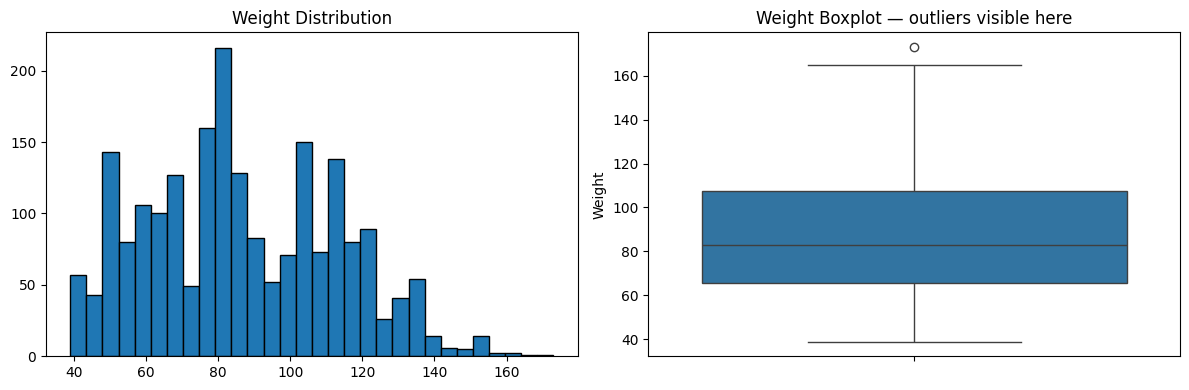

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Weight'], bins=30, edgecolor='black')
axes[0].set_title("Weight Distribution")
sns.boxplot(y=df['Weight'], ax=axes[1])
axes[1].set_title("Weight Boxplot — outliers visible here")
plt.tight_layout()
plt.show()